In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

from sven.nn import SvenWrapper
from experiments.nn import MLP
from sven.opt import Sven

import sys
sys.path.append('..')
import copy

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd, set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

from torch.nn.utils import parameters_to_vector, vector_to_parameters
from torch.func import functional_call, hessian, grad

Using device: cuda


### Hessian computation

In [2]:
def get_hessian(model,X,Y,loss_fn):
    params = parameters_to_vector(model.parameters())
    
    param_name_shape_sizes = []
    for name,param in model.named_parameters():
        param_name_shape_sizes.append((name,param.shape,param.numel()))
    
    def loss(params_vector, x, y):
        p = {}
        i = 0
        for (name, shape, size) in param_name_shape_sizes:
            p[name] = params_vector[i:i+size].view(shape)
            i += size
        pred = functional_call(model, p, x)
        L = loss_fn(pred, y)
        print("Loss:", L.item())
        return L

    H = hessian(loss)(params,X,Y).detach()
    G = grad(loss)(params,X,Y)
    return H, G

def get_hessian_sven(model,X,Y):
    def loss(params, x, y):
        pred = model.func_call(params, x)
        L = model.loss_fn(pred,y).mean()
        print("Loss:", L.item())
        return L
    H = hessian(loss)(model.params,X,Y).detach()
    G = grad(loss)(model.params,X,Y)
    return H, G

In [ ]:

# -----------------------------------------------------------------------
# Helper: Candidate optimizer-step computation
# -----------------------------------------------------------------------
import copy as _copy

def _get_adam_step_single(model, optimizer, xb, yb, loss_fn_scalar):
    """Return the Adam parameter update (delta theta) for a single batch without committing it."""
    dev = next(model.parameters()).device
    xb, yb = xb.to(dev), yb.to(dev)
    with torch.no_grad():
        params_before = parameters_to_vector(model.parameters()).clone()
    state_before = _copy.deepcopy(optimizer.state_dict())
    model.train()
    optimizer.zero_grad()
    # Ensure grad tracking is active for the forward/backward pass
    with torch.enable_grad():
        pred = model(xb)
        loss = loss_fn_scalar(pred, yb)
        loss.backward()
    optimizer.step()
    with torch.no_grad():
        params_after = parameters_to_vector(model.parameters()).clone()
        step = (params_after - params_before).cpu()
        # Restore model params and optimizer state
        vector_to_parameters(params_before, model.parameters())
    optimizer.load_state_dict(state_before)
    return step

@torch.no_grad()
def _get_sven_step_single(model_svd, optimizer_sven, xb, yb):
    """Return the Sven parameter update (delta theta) for a single batch without committing it.
    torch.func.jacrev used internally operates independently of the autograd tape."""
    dev = model_svd.device
    xb, yb = xb.to(dev), yb.to(dev)
    batch = (xb, yb)
    model_svd.loss_and_grad(batch)
    jacobian = model_svd.grads
    losses   = model_svd.losses
    VhT, S_inv, U_T = optimizer_sven._get_pinv(jacobian)
    step = Sven._compute_delta(U_T, S_inv, VhT, losses)
    step = (-optimizer_sven.lr * step).detach().cpu()
    del model_svd.grads, model_svd.losses, jacobian, VhT, S_inv, U_T
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return step

def get_avg_adam_step(model, optimizer, dataset, loss_fn_scalar, n_batches=8, batch_size=64, seed=42):
    """Average candidate Adam steps over `n_batches` random mini-batches."""
    gen = torch.Generator().manual_seed(seed)
    steps = []
    for _ in range(n_batches):
        idx = torch.randperm(len(dataset), generator=gen)[:batch_size]
        xb, yb = dataset[idx]
        steps.append(_get_adam_step_single(model, optimizer, xb, yb, loss_fn_scalar))
    return torch.stack(steps).mean(0)

def get_avg_sven_step(model_svd, optimizer_sven, dataset, n_batches=8, batch_size=64, seed=42):
    """Average candidate Sven steps over `n_batches` random mini-batches."""
    gen = torch.Generator().manual_seed(seed)
    steps = []
    for _ in range(n_batches):
        idx = torch.randperm(len(dataset), generator=gen)[:batch_size]
        xb, yb = dataset[idx]
        steps.append(_get_sven_step_single(model_svd, optimizer_sven, xb.to(model_svd.device), yb.to(model_svd.device)))
    return torch.stack(steps).mean(0)

@torch.no_grad()
def compute_step_alignment(V_eigs, step, device):
    """
    Project `step` onto the Hessian eigenvectors.
    V_eigs: (P, P) tensor, columns are eigenvectors (ascending eigenvalue order, from eigh).
    Returns a numpy array of shape (P,): V_eigs.T @ step / ||step||.
    """
    step = step.to(device)
    return (V_eigs.T @ step / torch.linalg.norm(step, ord=2)).detach().cpu().numpy()


# Toy linear model hessian

### Define dataset

In [3]:
SEED = 2184
set_seed(SEED)

D = 128
noise_std = 0.1
Ntrain = 10_000
Nval = 1_000
w = torch.randn(1,D)

xtrain = torch.randn(Ntrain, D)
xval = torch.randn(Nval, D)
ytrain = F.linear(xtrain,w) + noise_std * torch.randn(xtrain.shape[0],1)
yval = F.linear(xval,w) + noise_std * torch.randn(xval.shape[0],1)

train_dataset = TensorDataset(xtrain, ytrain)
val_dataset = TensorDataset(xval, yval)


### Define model

In [4]:
SEED = 437438
set_seed(SEED)
model_base = nn.Linear(D, 1, bias=False).to(device)
init_state = copy.deepcopy(model_base.state_dict())
del model_base # free memory

### Training params

In [5]:
LOADER_SEED = 12345
batch_size = 64
n_epoch = 100

### Train Adam

In [ ]:
model_adam = nn.Linear(D, 1, bias=False).to(device)
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

LR_ADAM = 1e-2

optimizer = torch.optim.Adam(model_adam.parameters(), lr=LR_ADAM)
def loss_fn(pred,y):
    return (pred-y).pow(2).mean()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

x_pre, y_pre = train_dataset[torch.randperm(len(train_dataset))[:5000]]
H_pre, G_pre = get_hessian(model_adam, x_pre.to(device), y_pre.to(device), loss_fn)
eigs_pre, V_pre = torch.linalg.eigh(H_pre)
VG_dots_pre = V_pre.T @ G_pre / torch.linalg.norm(G_pre, ord=2)
del H_pre, V_pre, G_pre
eigs_pre = eigs_pre.detach().cpu().numpy()
VG_dots_pre = VG_dots_pre.detach().cpu().numpy()

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

x_post, y_post = train_dataset[torch.randperm(len(train_dataset))[:5000]]
H_post, G_post = get_hessian(model_adam, x_post.to(device), y_post.to(device), loss_fn)
eigs_post, V_post = torch.linalg.eigh(H_post)
VG_dots_post = V_post.T @ G_post / torch.linalg.norm(G_post, ord=2)

# Compute candidate Adam step alignment before releasing V_post
step_adam = get_avg_adam_step(model_adam, optimizer, train_dataset, loss_fn, n_batches=8, batch_size=batch_size, seed=42)
VS_dots_post_adam = compute_step_alignment(V_post, step_adam, device)

del H_post, G_post, V_post
eigs_post = eigs_post.detach().cpu().numpy()
VG_dots_post = VG_dots_post.detach().cpu().numpy()


Loss: 127.84980010986328
Loss: 127.84980010986328
Using device cuda


100%|██████████| 100/100 [00:38<00:00,  2.57it/s]

Loss: 0.01919666863977909
Loss: 0.01919666863977909


### Train Sven

In [ ]:
model_svd = nn.Linear(D, 1, bias=False).to(device)
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn(pred,y):
    return (pred-y).pow(2).sum(dim=1)

LR_SVD = 0.5
RTOL = 1e-3
K = 4


model_svd = SvenWrapper(model_svd, loss_fn, device=device)
optimizer_sven = Sven(model_svd,lr=LR_SVD,k=K,rtol=RTOL,track_svd_info=True,svd_mode='randomized', use_rmsprop=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

x_pre_sven, y_pre_sven = train_dataset[torch.randperm(len(train_dataset))[:5000]]
H_pre_sven, G_pre_sven = get_hessian_sven(model_svd, x_pre_sven.to(device), y_pre_sven.to(device))
eigs_pre_sven, V_pre_sven = torch.linalg.eigh(H_pre_sven)
VG_dots_pre_sven = V_pre_sven.T @ G_pre_sven / torch.linalg.norm(G_pre_sven, ord=2)
del H_pre_sven, V_pre_sven, G_pre_sven
eigs_pre_sven = eigs_pre_sven.detach().cpu().numpy()
VG_dots_pre_sven = VG_dots_pre_sven.detach().cpu().numpy()

model_svd, losses_svd, optimizer_sven = train_loop_svd(model_svd,optimizer_sven,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info = optimizer_sven.svd_info

x_post_sven, y_post_sven = train_dataset[torch.randperm(len(train_dataset))[:5000]]
H_post_sven, G_post_sven = get_hessian_sven(model_svd, x_post_sven.to(device), y_post_sven.to(device))
eigs_post_sven, V_post_sven = torch.linalg.eigh(H_post_sven)
VG_dots_post_sven = V_post_sven.T @ G_post_sven / torch.linalg.norm(G_post_sven, ord=2)

# Compute candidate Sven step alignment before releasing V_post_sven
step_sven = get_avg_sven_step(model_svd, optimizer_sven, train_dataset, n_batches=8, batch_size=batch_size, seed=42)
VS_dots_post_sven = compute_step_alignment(V_post_sven, step_sven, device)

del H_post_sven, G_post_sven, V_post_sven
eigs_post_sven = eigs_post_sven.detach().cpu().numpy()
VG_dots_post_sven = VG_dots_post_sven.detach().cpu().numpy()


Loss: 125.95555877685547
Loss: 125.95555877685547


100%|██████████| 100/100 [01:16<00:00,  1.30it/s]

Loss: 0.011188581585884094
Loss: 0.011188581585884094


### Compare

(0.0, 100.0)

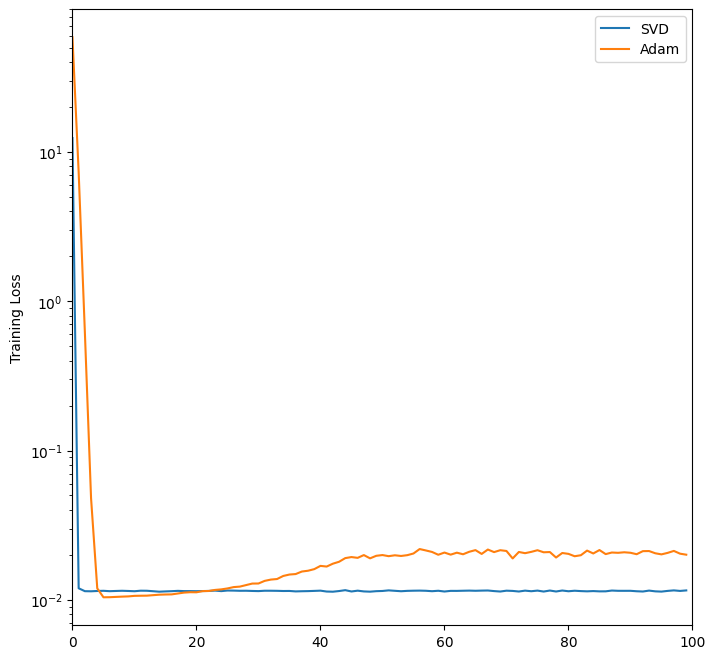

In [12]:
plt.figure(figsize=(8,8))
plt.plot(losses_svd['train'],label='SVD')
plt.plot(losses_adam['train'],label='Adam')
plt.legend()
plt.ylabel("Training Loss")
plt.yscale('log')
plt.xlim([0,100])

### Look at the Hessian

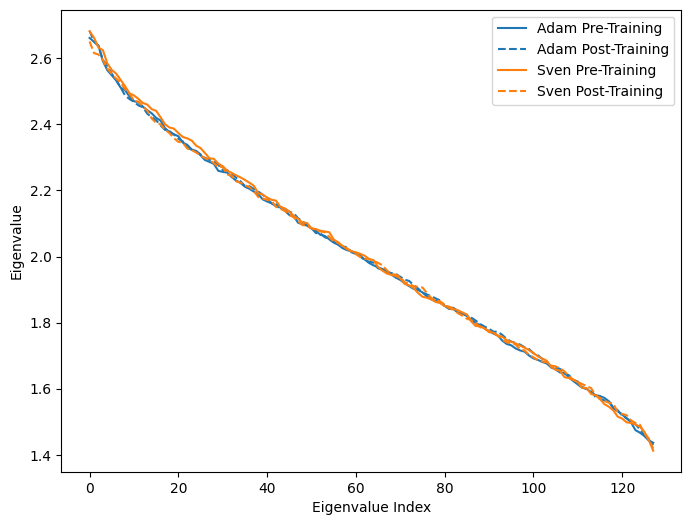

In [13]:
plt.figure(figsize=(8,6))
plt.plot(eigs_pre[::-1], label='Adam Pre-Training',color='C0')
plt.plot(eigs_post[::-1], label='Adam Post-Training',color='C0',linestyle='--')
plt.plot(eigs_pre_sven[::-1], label='Sven Pre-Training',color='C1')
plt.plot(eigs_post_sven[::-1], label='Sven Post-Training',color='C1',linestyle='--')
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue")
plt.legend()

<>:7: SyntaxWarning: invalid escape sequence '\|'
<>:7: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_1148555/4172419790.py:7: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel("Eigenvector-Gradient Alignment ($v_i^T g / \|g\|$)")


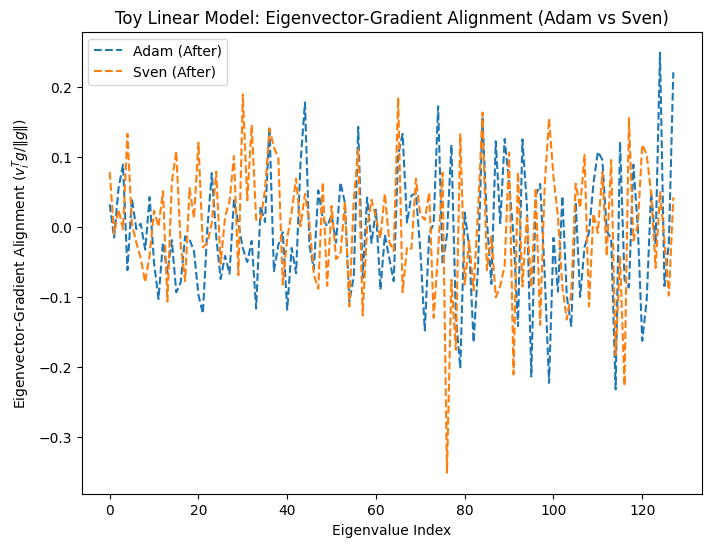

In [14]:
plt.figure(figsize=(8, 6))
#plt.plot(VG_dots_pre,      label='Adam (Before)', color='C0')
plt.plot(VG_dots_post,      label='Adam (After)',  color='C0', linestyle='--')
#plt.plot(VG_dots_pre_sven,  label='Sven (Before)', color='C1')
plt.plot(VG_dots_post_sven, label='Sven (After)',  color='C1', linestyle='--')
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvector-Gradient Alignment ($v_i^T g / \|g\|$)")
plt.title("Toy Linear Model: Eigenvector-Gradient Alignment (Adam vs Sven)")
plt.legend()

### Candidate Step Alignment (Adam vs Sven)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Adam: gradient vs step alignment (w.r.t. Adam model Hessian eigenvectors)
axes[0].plot(VG_dots_post,     label='Gradient (Adam, After)', color='C0', linestyle='--')
axes[0].plot(VS_dots_post_adam, label='Step (Adam, After)',    color='C0', linestyle='-', alpha=0.8)
axes[0].set_xlabel("Eigenvalue Index (Smallest → Largest)")
axes[0].set_ylabel("Alignment")
axes[0].set_title("Toy Linear: Adam – Gradient vs Step alignment")
axes[0].legend()

# Sven: gradient vs step alignment (w.r.t. Sven model Hessian eigenvectors)
axes[1].plot(VG_dots_post_sven,  label='Gradient (Sven, After)', color='C1', linestyle='--')
axes[1].plot(VS_dots_post_sven,  label='Step (Sven, After)',     color='C1', linestyle='-', alpha=0.8)
axes[1].set_xlabel("Eigenvalue Index (Smallest → Largest)")
axes[1].set_ylabel("Alignment")
axes[1].set_title("Toy Linear: Sven – Gradient vs Step alignment")
axes[1].legend()

plt.tight_layout()
plt.show()


# Toy 1D dataset

In [15]:
from experiments.datasets import Toy1DRegressionDataset

toy_1d = Toy1DRegressionDataset(seed=12345,n_train=10_000,n_val=2_000,n_test=10_000)
train_dataset = toy_1d.train_dataset
val_dataset = toy_1d.val_dataset

In [16]:
def make_model():
    return MLP(input_dim=1,
               hidden_dims=[16,16],
               output_dim=1)

set_seed(57389)
mlp_base = make_model()
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

### Training params

In [17]:
LOADER_SEED = 12345
batch_size = 64
n_epoch = 100

### Train Adam

In [ ]:
model_adam = make_model().to(device)
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

LR_ADAM = 1e-3

optimizer = torch.optim.Adam(model_adam.parameters(), lr=LR_ADAM)
def loss_fn(pred,y):
    return (pred-y).pow(2).mean()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

x_pre, y_pre = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_pre, G_pre = get_hessian(model_adam, x_pre.to(device), y_pre.to(device), loss_fn)
eigs_pre, V_pre = torch.linalg.eigh(H_pre)
VG_dots_pre = V_pre.T @ G_pre / torch.linalg.norm(G_pre, ord=2)
del H_pre, G_pre, V_pre
eigs_pre = eigs_pre.detach().cpu().numpy()
VG_dots_pre = VG_dots_pre.detach().cpu().numpy()

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

x_post, y_post = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_post, G_post = get_hessian(model_adam, x_post.to(device), y_post.to(device), loss_fn)
eigs_post, V_post = torch.linalg.eigh(H_post)
VG_dots_post = V_post.T @ G_post / torch.linalg.norm(G_post, ord=2)

# Compute candidate Adam step alignment before releasing V_post
step_adam = get_avg_adam_step(model_adam, optimizer, train_dataset, loss_fn, n_batches=8, batch_size=batch_size, seed=42)
VS_dots_post_adam = compute_step_alignment(V_post, step_adam, device)

del H_post, G_post, V_post
eigs_post = eigs_post.detach().cpu().numpy()
VG_dots_post = VG_dots_post.detach().cpu().numpy()


Loss: 0.9571583867073059
Loss: 0.9571583867073059
Using device cuda


100%|██████████| 100/100 [01:07<00:00,  1.49it/s]

Loss: 5.29568933416158e-06
Loss: 5.29568933416158e-06


### Train Sven

In [ ]:
model_svd = make_model().to(device)
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn(pred,y):
    return (pred-y).pow(2).sum(dim=1)

LR_SVD = 0.5
RTOL = 1e-3
K = 16


model_svd = SvenWrapper(model_svd, loss_fn, device=device)
optimizer_sven = Sven(model_svd,lr=LR_SVD,k=K,rtol=RTOL,track_svd_info=True,svd_mode='randomized', use_rmsprop=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

x_pre_sven, y_pre_sven = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_pre_sven, G_pre_sven = get_hessian_sven(model_svd, x_pre_sven.to(device), y_pre_sven.to(device))
eigs_pre_sven, V_pre_sven = torch.linalg.eigh(H_pre_sven)
VG_dots_pre_sven = V_pre_sven.T @ G_pre_sven / torch.linalg.norm(G_pre_sven, ord=2)
del H_pre_sven, G_pre_sven, V_pre_sven
eigs_pre_sven = eigs_pre_sven.detach().cpu().numpy()
VG_dots_pre_sven = VG_dots_pre_sven.detach().cpu().numpy()

model_svd, losses_svd, optimizer_sven = train_loop_svd(model_svd,optimizer_sven,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info = optimizer_sven.svd_info

x_post_sven, y_post_sven = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_post_sven, G_post_sven = get_hessian_sven(model_svd, x_post_sven.to(device), y_post_sven.to(device))
eigs_post_sven, V_post_sven = torch.linalg.eigh(H_post_sven)
VG_dots_post_sven = V_post_sven.T @ G_post_sven / torch.linalg.norm(G_post_sven, ord=2)

# Compute candidate Sven step alignment before releasing V_post_sven
step_sven = get_avg_sven_step(model_svd, optimizer_sven, train_dataset, n_batches=8, batch_size=batch_size, seed=42)
VS_dots_post_sven = compute_step_alignment(V_post_sven, step_sven, device)

del H_post_sven, G_post_sven, V_post_sven
eigs_post_sven = eigs_post_sven.detach().cpu().numpy()
VG_dots_post_sven = VG_dots_post_sven.detach().cpu().numpy()


Loss: 0.9571583867073059
Loss: 0.9571583867073059


100%|██████████| 100/100 [02:11<00:00,  1.31s/it]

Loss: 4.718397576652933e-06
Loss: 4.718397576652933e-06


### Compare

(0.0, 100.0)

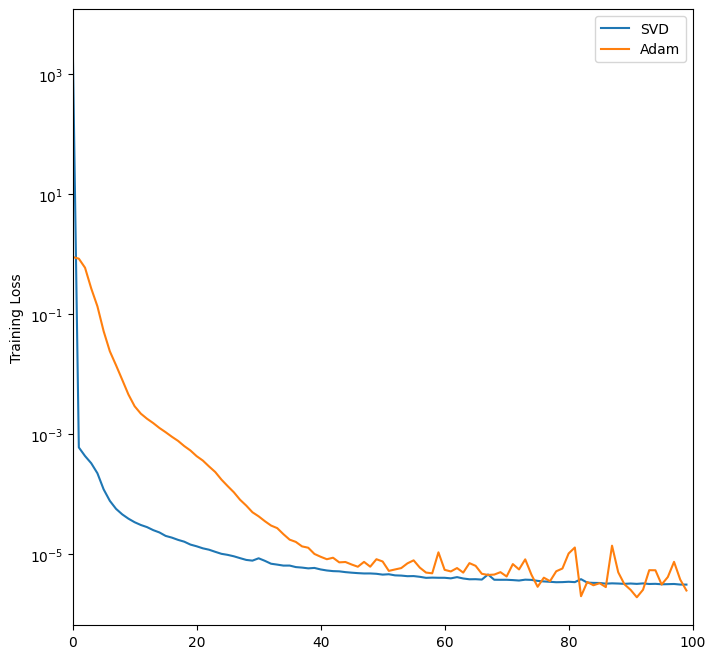

In [20]:
plt.figure(figsize=(8,8))
plt.plot(losses_svd['train'],label='SVD')
plt.plot(losses_adam['train'],label='Adam')
plt.legend()
plt.ylabel("Training Loss")
plt.yscale('log')
plt.xlim([0,100])

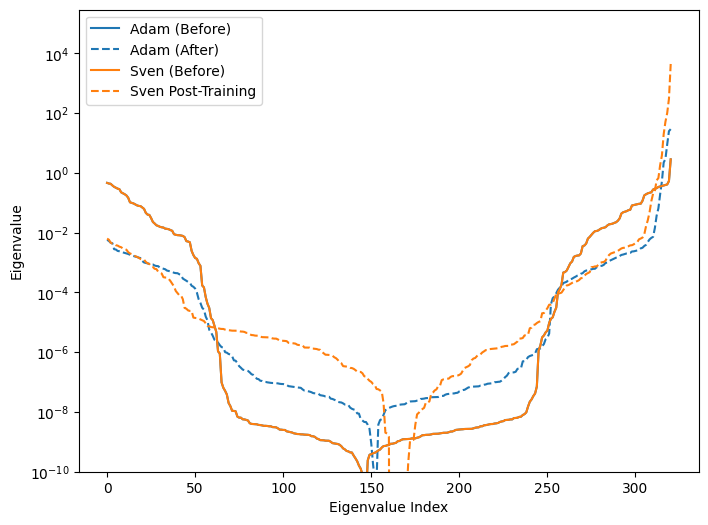

In [23]:
plt.figure(figsize=(8,6))
plt.plot(np.abs(eigs_pre), label='Adam (Before)',color='C0')
plt.plot(np.abs(eigs_post), label='Adam (After)',color='C0',linestyle='--')
plt.plot(np.abs(eigs_pre_sven), label='Sven (Before)',color='C1')
plt.plot(np.abs(eigs_post_sven), label='Sven Post-Training',color='C1',linestyle='--')
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue")
plt.yscale('log')
plt.ylim([1e-10,None])
plt.legend()

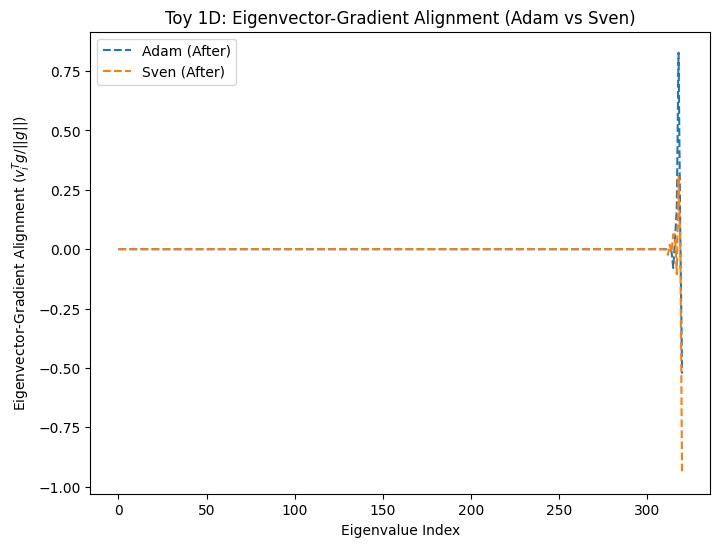

In [24]:
plt.figure(figsize=(8, 6))
#plt.plot(VG_dots_pre,      label='Adam (Before)', color='C0')
plt.plot(VG_dots_post,      label='Adam (After)',  color='C0', linestyle='--')
#plt.plot(VG_dots_pre_sven,  label='Sven (Before)', color='C1')
plt.plot(VG_dots_post_sven, label='Sven (After)',  color='C1', linestyle='--')
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvector-Gradient Alignment ($v_i^T g / ||g||$)")
plt.title("Toy 1D: Eigenvector-Gradient Alignment (Adam vs Sven)")
plt.legend()

### Candidate Step Alignment (Adam vs Sven)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(VG_dots_post,     label='Gradient (Adam, After)', color='C0', linestyle='--')
axes[0].plot(VS_dots_post_adam, label='Step (Adam, After)',    color='C0', linestyle='-', alpha=0.8)
axes[0].set_xlabel("Eigenvalue Index (Smallest → Largest)")
axes[0].set_ylabel("Alignment")
axes[0].set_title("Toy 1D: Adam – Gradient vs Step alignment")
axes[0].legend()

axes[1].plot(VG_dots_post_sven,  label='Gradient (Sven, After)', color='C1', linestyle='--')
axes[1].plot(VS_dots_post_sven,  label='Step (Sven, After)',     color='C1', linestyle='-', alpha=0.8)
axes[1].set_xlabel("Eigenvalue Index (Smallest → Largest)")
axes[1].set_ylabel("Alignment")
axes[1].set_title("Toy 1D: Sven – Gradient vs Step alignment")
axes[1].legend()

plt.tight_layout()
plt.show()


# MNIST

In [29]:
from experiments.datasets import MNISTDataset

toy_1d = MNISTDataset()
train_dataset = toy_1d.train_dataset[:10_000]
val_dataset = toy_1d.val_dataset[:10_000]
train_dataset = TensorDataset(train_dataset[0], train_dataset[1])
val_dataset = TensorDataset(val_dataset[0], val_dataset[1])

In [30]:
def make_model():
    return MLP(input_dim=784,
               hidden_dims=[16,16],
               output_dim=10)

set_seed(57389)
mlp_base = make_model()
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

### Training params

In [31]:
LOADER_SEED = 12345
batch_size = 64
n_epoch = 20

### Train Adam

In [ ]:
model_adam = make_model().to(device)
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

torch.cuda.empty_cache()

LR_ADAM = 1e-3

optimizer = torch.optim.Adam(model_adam.parameters(), lr=LR_ADAM)
def loss_fn(pred,y):
    y = F.one_hot(y, num_classes=10).to(pred)
    return (pred-y).pow(2).sum(dim=1).mean()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

x_pre, y_pre = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_pre, G_pre = get_hessian(model_adam, x_pre.to(device), y_pre.to(device), loss_fn)
eigs_pre, V_pre = torch.linalg.eigh(H_pre)
VG_dots_pre = V_pre.T @ G_pre / torch.linalg.norm(G_pre, ord=2)
del H_pre, V_pre, G_pre
eigs_pre = eigs_pre.detach().cpu().numpy()
VG_dots_pre = VG_dots_pre.detach().cpu().numpy()

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

x_post, y_post = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_post, G_post = get_hessian(model_adam, x_post.to(device), y_post.to(device), loss_fn)
eigs_post, V_post = torch.linalg.eigh(H_post)
VG_dots_post = V_post.T @ G_post / torch.linalg.norm(G_post, ord=2)

# Compute candidate Adam step alignment before releasing V_post
step_adam = get_avg_adam_step(model_adam, optimizer, train_dataset, loss_fn, n_batches=8, batch_size=batch_size, seed=42)
VS_dots_post_adam = compute_step_alignment(V_post, step_adam, device)

del H_post, G_post, V_post
eigs_post = eigs_post.detach().cpu().numpy()
VG_dots_post = VG_dots_post.detach().cpu().numpy()


Loss: 1.3089094161987305
Loss: 1.3089094161987305
Using device cuda


100%|██████████| 20/20 [00:14<00:00,  1.37it/s]


Loss: 0.07253244519233704
Loss: 0.07253244519233704


### Train Sven

In [ ]:
model_svd = make_model().to(device)
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn(pred,y):
    y = F.one_hot(y,num_classes=10).to(pred)
    return (pred-y).pow(2).sum(dim=1)

LR_SVD = 0.5
RTOL = 1e-3
K = 64

torch.cuda.empty_cache()

model_svd = SvenWrapper(model_svd, loss_fn, device=device)
optimizer_sven = Sven(model_svd,lr=LR_SVD,k=K,rtol=RTOL,track_svd_info=True,svd_mode='randomized', use_rmsprop=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

x_pre_sven, y_pre_sven = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_pre_sven, G_pre_sven = get_hessian_sven(model_svd, x_pre_sven.to(device), y_pre_sven.to(device))
eigs_pre_sven, V_pre_sven = torch.linalg.eigh(H_pre_sven)
VG_dots_pre_sven = V_pre_sven.T @ G_pre_sven / torch.linalg.norm(G_pre_sven, ord=2)
del H_pre_sven, V_pre_sven, G_pre_sven
eigs_pre_sven = eigs_pre_sven.detach().cpu().numpy()
VG_dots_pre_sven = VG_dots_pre_sven.detach().cpu().numpy()

model_svd, losses_svd, optimizer_sven = train_loop_svd(model_svd,optimizer_sven,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info = optimizer_sven.svd_info

x_post_sven, y_post_sven = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_post_sven, G_post_sven = get_hessian_sven(model_svd, x_post_sven.to(device), y_post_sven.to(device))
eigs_post_sven, V_post_sven = torch.linalg.eigh(H_post_sven)
VG_dots_post_sven = V_post_sven.T @ G_post_sven / torch.linalg.norm(G_post_sven, ord=2)

# Compute candidate Sven step alignment before releasing V_post_sven
step_sven = get_avg_sven_step(model_svd, optimizer_sven, train_dataset, n_batches=8, batch_size=batch_size, seed=42)
VS_dots_post_sven = compute_step_alignment(V_post_sven, step_sven, device)

del H_post_sven, G_post_sven, V_post_sven
eigs_post_sven = eigs_post_sven.detach().cpu().numpy()
VG_dots_post_sven = VG_dots_post_sven.detach().cpu().numpy()


Loss: 1.3089094161987305
Loss: 1.3089094161987305


100%|██████████| 20/20 [00:27<00:00,  1.38s/it]


Loss: 0.09467998147010803
Loss: 0.09467998147010803


### Compare

(0.0, 20.0)

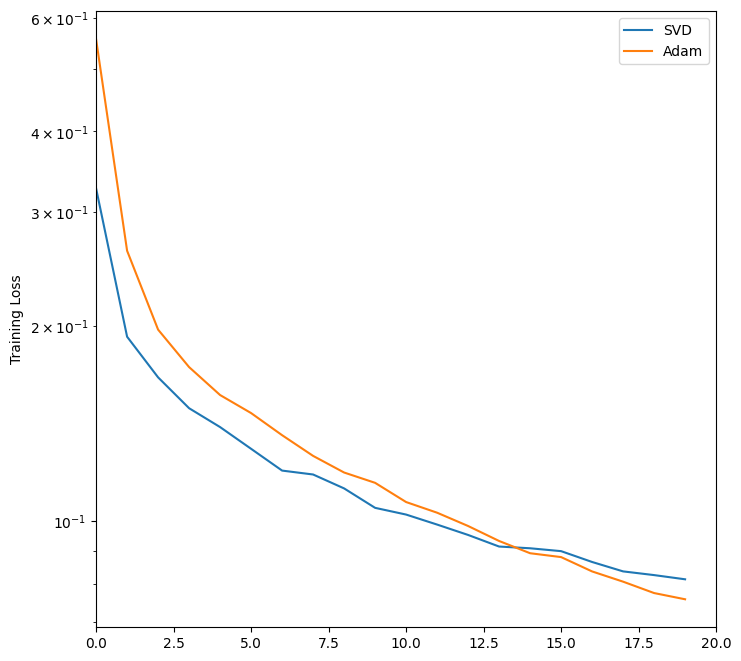

In [35]:
plt.figure(figsize=(8,8))
plt.plot(losses_svd['train'],label='SVD')
plt.plot(losses_adam['train'],label='Adam')
plt.legend()
plt.ylabel("Training Loss")
plt.yscale('log')
plt.xlim([0,20])

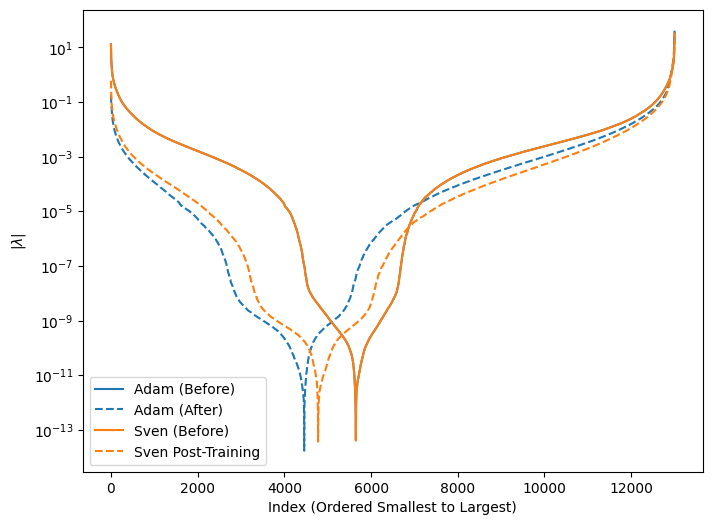

In [36]:
plt.figure(figsize=(8,6))
plt.plot(np.abs(eigs_pre), label='Adam (Before)',color='C0')
plt.plot(np.abs(eigs_post), label='Adam (After)',color='C0',linestyle='--')
plt.plot(np.abs(eigs_pre_sven), label='Sven (Before)',color='C1')
plt.plot(np.abs(eigs_post_sven), label='Sven Post-Training',color='C1',linestyle='--')
plt.xlabel("Index (Ordered Smallest to Largest)")
plt.ylabel("$|\\lambda|$")
plt.yscale('log')
plt.legend()

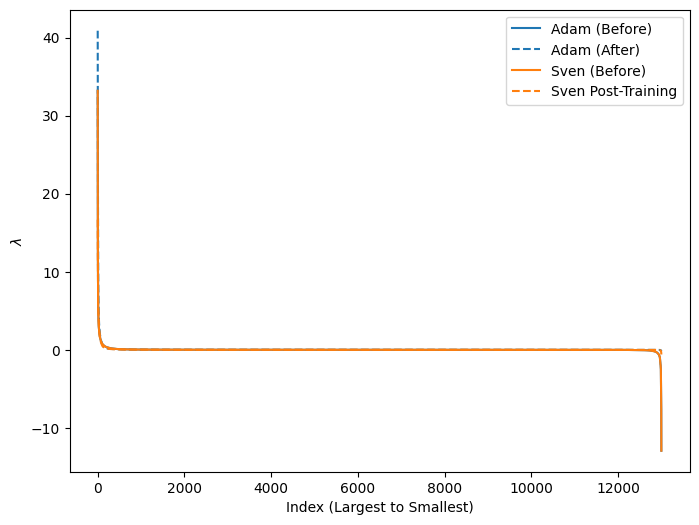

In [37]:
plt.figure(figsize=(8,6))
plt.plot(eigs_pre[::-1], label='Adam (Before)',color='C0')
plt.plot(eigs_post[::-1], label='Adam (After)',color='C0',linestyle='--')
plt.plot(eigs_pre_sven[::-1], label='Sven (Before)',color='C1')
plt.plot(eigs_post_sven[::-1], label='Sven Post-Training',color='C1',linestyle='--')
plt.xlabel("Index (Largest to Smallest)")
plt.ylabel("$\\lambda$")
#plt.yscale('log')
plt.legend()

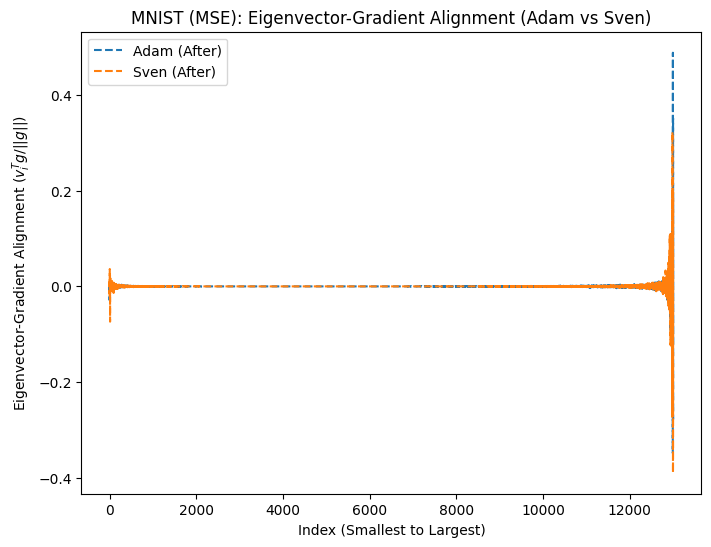

In [40]:
plt.figure(figsize=(8, 6))
#plt.plot(VG_dots_pre,      label='Adam (Before)', color='C0')
plt.plot(VG_dots_post,      label='Adam (After)',  color='C0', linestyle='--')
#plt.plot(VG_dots_pre_sven,  label='Sven (Before)', color='C1')
plt.plot(VG_dots_post_sven, label='Sven (After)',  color='C1', linestyle='--')
plt.xlabel("Index (Smallest to Largest)")
plt.ylabel("Eigenvector-Gradient Alignment ($v_i^T g / ||g||$)")
plt.title("MNIST (MSE): Eigenvector-Gradient Alignment (Adam vs Sven)")
plt.legend()

### Candidate Step Alignment (Adam vs Sven)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(VG_dots_post,     label='Gradient (Adam, After)', color='C0', linestyle='--')
axes[0].plot(VS_dots_post_adam, label='Step (Adam, After)',    color='C0', linestyle='-', alpha=0.8)
axes[0].set_xlabel("Eigenvalue Index (Smallest → Largest)")
axes[0].set_ylabel("Alignment")
axes[0].set_title("MNIST (MSE): Adam – Gradient vs Step alignment")
axes[0].legend()

axes[1].plot(VG_dots_post_sven,  label='Gradient (Sven, After)', color='C1', linestyle='--')
axes[1].plot(VS_dots_post_sven,  label='Step (Sven, After)',     color='C1', linestyle='-', alpha=0.8)
axes[1].set_xlabel("Eigenvalue Index (Smallest → Largest)")
axes[1].set_ylabel("Alignment")
axes[1].set_title("MNIST (MSE): Sven – Gradient vs Step alignment")
axes[1].legend()

plt.tight_layout()
plt.show()


# MNIST cross-entropy

In [41]:
from experiments.datasets import MNISTDataset

toy_1d = MNISTDataset()
train_dataset = toy_1d.train_dataset[:10_000]
val_dataset = toy_1d.val_dataset[:10_000]
train_dataset = TensorDataset(train_dataset[0], train_dataset[1])
val_dataset = TensorDataset(val_dataset[0], val_dataset[1])

In [42]:
def make_model():
    return MLP(input_dim=784,
               hidden_dims=[16,16],
               output_dim=10)

set_seed(57389)
mlp_base = make_model()
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

### Training params

In [43]:
LOADER_SEED = 12345
batch_size = 64
n_epoch = 20

### Train Adam

In [ ]:
model_adam = make_model()
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

LR_ADAM = 1e-3

torch.cuda.empty_cache()

optimizer = torch.optim.Adam(model_adam.parameters(), lr=LR_ADAM)
def loss_fn(pred,y):
    return nn.CrossEntropyLoss(reduction='mean')(pred,y)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

x_pre, y_pre = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_pre, G_pre = get_hessian(model_adam, x_pre.to(device), y_pre.to(device), loss_fn)
eigs_pre, V_pre = torch.linalg.eigh(H_pre)
VG_dots_pre = V_pre.T @ G_pre / torch.linalg.norm(G_pre, ord=2)
del H_pre, V_pre, G_pre
eigs_pre = eigs_pre.detach().cpu().numpy()
VG_dots_pre = VG_dots_pre.detach().cpu().numpy()

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

x_post, y_post = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_post, G_post = get_hessian(model_adam, x_post.to(device), y_post.to(device), loss_fn)
eigs_post, V_post = torch.linalg.eigh(H_post)
VG_dots_post = V_post.T @ G_post / torch.linalg.norm(G_post, ord=2)

# Compute candidate Adam step alignment before releasing V_post
step_adam = get_avg_adam_step(model_adam, optimizer, train_dataset, loss_fn, n_batches=8, batch_size=batch_size, seed=42)
VS_dots_post_adam = compute_step_alignment(V_post, step_adam, device)

del H_post, G_post, V_post
eigs_post = eigs_post.detach().cpu().numpy()
VG_dots_post = VG_dots_post.detach().cpu().numpy()


Loss: 2.323521375656128
Loss: 2.323521375656128
Using device cuda


100%|██████████| 20/20 [00:13<00:00,  1.43it/s]


Loss: 0.06501376628875732
Loss: 0.06501376628875732


### Train Sven

In [ ]:
model_svd = make_model().to(device)
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn(pred,y):
    return F.cross_entropy(pred, y, reduction='none')

LR_SVD = 0.5
RTOL = 1e-3
K = 64

torch.cuda.empty_cache()

model_svd = SvenWrapper(model_svd, loss_fn, device=device)
optimizer_sven = Sven(model_svd,lr=LR_SVD,k=K,rtol=RTOL,track_svd_info=True,svd_mode='randomized', use_rmsprop=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

x_pre_sven, y_pre_sven = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_pre_sven, G_pre_sven = get_hessian_sven(model_svd, x_pre_sven.to(device), y_pre_sven.to(device))
eigs_pre_sven, V_pre_sven = torch.linalg.eigh(H_pre_sven)
VG_dots_pre_sven = V_pre_sven.T @ G_pre_sven / torch.linalg.norm(G_pre_sven, ord=2)
del H_pre_sven, V_pre_sven, G_pre_sven
eigs_pre_sven = eigs_pre_sven.detach().cpu().numpy()
VG_dots_pre_sven = VG_dots_pre_sven.detach().cpu().numpy()

model_svd, losses_svd, optimizer_sven = train_loop_svd(model_svd,optimizer_sven,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info = optimizer_sven.svd_info

x_post_sven, y_post_sven = train_dataset[torch.randperm(len(train_dataset),generator=torch.Generator().manual_seed(12345))[:5000]]
H_post_sven, G_post_sven = get_hessian_sven(model_svd, x_post_sven.to(device), y_post_sven.to(device))
eigs_post_sven, V_post_sven = torch.linalg.eigh(H_post_sven)
VG_dots_post_sven = V_post_sven.T @ G_post_sven / torch.linalg.norm(G_post_sven, ord=2)

# Compute candidate Sven step alignment before releasing V_post_sven
step_sven = get_avg_sven_step(model_svd, optimizer_sven, train_dataset, n_batches=8, batch_size=batch_size, seed=42)
VS_dots_post_sven = compute_step_alignment(V_post_sven, step_sven, device)

del H_post_sven, G_post_sven, V_post_sven
eigs_post_sven = eigs_post_sven.detach().cpu().numpy()
VG_dots_post_sven = VG_dots_post_sven.detach().cpu().numpy()


Loss: 2.323521375656128
Loss: 2.323521375656128


100%|██████████| 20/20 [00:35<00:00,  1.78s/it]


Loss: 0.1163889616727829
Loss: 0.1163889616727829


### Compare

(0.0, 20.0)

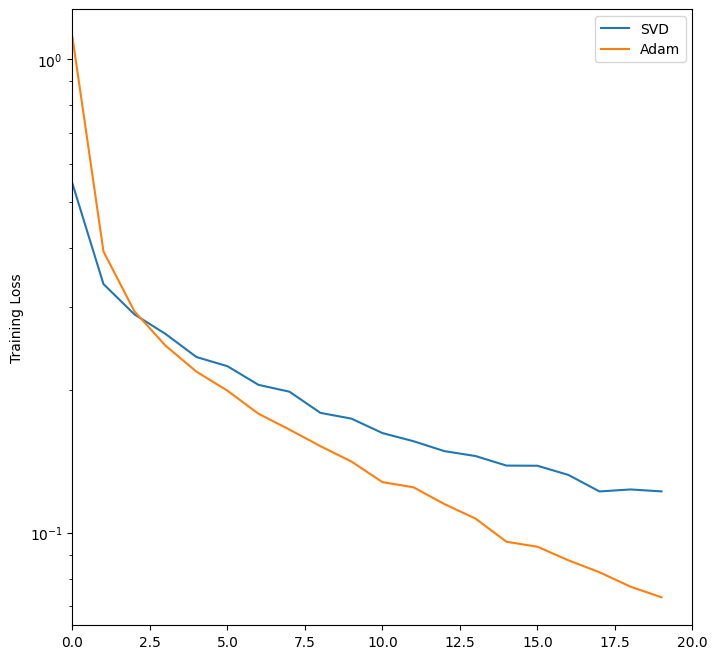

In [46]:
plt.figure(figsize=(8,8))
plt.plot(losses_svd['train'],label='SVD')
plt.plot(losses_adam['train'],label='Adam')
plt.legend()
plt.ylabel("Training Loss")
plt.yscale('log')
plt.xlim([0,20])

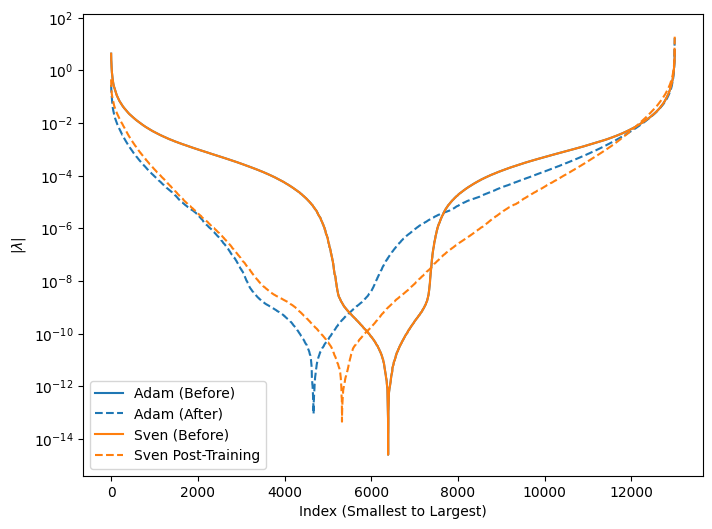

In [47]:
plt.figure(figsize=(8,6))
plt.plot(np.abs(eigs_pre), label='Adam (Before)',color='C0')
plt.plot(np.abs(eigs_post), label='Adam (After)',color='C0',linestyle='--')
plt.plot(np.abs(eigs_pre_sven), label='Sven (Before)',color='C1')
plt.plot(np.abs(eigs_post_sven), label='Sven Post-Training',color='C1',linestyle='--')
plt.xlabel("Index (Smallest to Largest)")
plt.ylabel("$|\\lambda|$")
plt.yscale('log')
plt.legend()

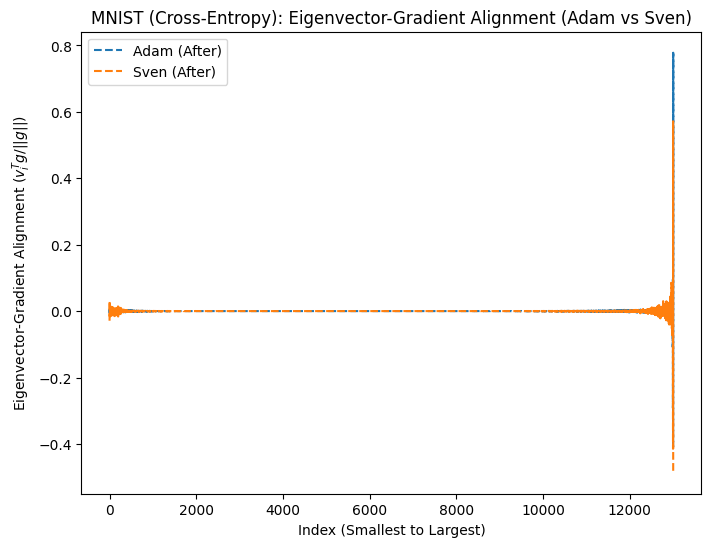

In [48]:
plt.figure(figsize=(8, 6))
#plt.plot(VG_dots_pre,      label='Adam (Before)', color='C0')
plt.plot(VG_dots_post,      label='Adam (After)',  color='C0', linestyle='--')
#plt.plot(VG_dots_pre_sven,  label='Sven (Before)', color='C1')
plt.plot(VG_dots_post_sven, label='Sven (After)',  color='C1', linestyle='--')
plt.xlabel("Index (Smallest to Largest)")
plt.ylabel("Eigenvector-Gradient Alignment ($v_i^T g / ||g||$)")
plt.title("MNIST (Cross-Entropy): Eigenvector-Gradient Alignment (Adam vs Sven)")
plt.legend()

### Candidate Step Alignment (Adam vs Sven)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(VG_dots_post,     label='Gradient (Adam, After)', color='C0', linestyle='--')
axes[0].plot(VS_dots_post_adam, label='Step (Adam, After)',    color='C0', linestyle='-', alpha=0.8)
axes[0].set_xlabel("Eigenvalue Index (Smallest → Largest)")
axes[0].set_ylabel("Alignment")
axes[0].set_title("MNIST (Cross-Entropy): Adam – Gradient vs Step alignment")
axes[0].legend()

axes[1].plot(VG_dots_post_sven,  label='Gradient (Sven, After)', color='C1', linestyle='--')
axes[1].plot(VS_dots_post_sven,  label='Step (Sven, After)',     color='C1', linestyle='-', alpha=0.8)
axes[1].set_xlabel("Eigenvalue Index (Smallest → Largest)")
axes[1].set_ylabel("Alignment")
axes[1].set_title("MNIST (Cross-Entropy): Sven – Gradient vs Step alignment")
axes[1].legend()

plt.tight_layout()
plt.show()


# CA housing

### Define dataset

In [6]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_all = housing.data.astype(np.float32)   # (20640, 8)
y_all = housing.target.astype(np.float32).reshape(-1, 1)

# Normalize features and targets
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_all = scaler_X.fit_transform(X_all)
y_all = scaler_y.fit_transform(y_all)

Ntrain = 16000
X_train = torch.tensor(X_all[:Ntrain])
y_train = torch.tensor(y_all[:Ntrain])
X_val   = torch.tensor(X_all[Ntrain:])
y_val   = torch.tensor(y_all[Ntrain:])

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val,   y_val)
print(f"Train: {X_train.shape}, Val: {X_val.shape}")

Train: torch.Size([16000, 8]), Val: torch.Size([4640, 8])


### Define model

In [7]:
def make_model():
    return MLP(input_dim=8, hidden_dims=[16, 16], output_dim=1)

set_seed(57389)
mlp_base = make_model()
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base

### Training params

In [14]:
LOADER_SEED = 12345
batch_size = 128
n_epoch = 100

### Train Adam

In [ ]:
model_adam = make_model().to(device)
model_adam.load_state_dict(init_state)

LR_ADAM = 1e-3
optimizer = torch.optim.Adam(model_adam.parameters(), lr=LR_ADAM)

def loss_fn(pred, y):
    return (pred - y).pow(2).mean()

torch.cuda.empty_cache()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader  = DataLoader(val_dataset,   batch_size=256, shuffle=False)

x_pre, y_pre = train_dataset[torch.randperm(len(train_dataset), generator=torch.Generator().manual_seed(12345))[:5000]]
H_pre, G_pre = get_hessian(model_adam, x_pre.to(device), y_pre.to(device), loss_fn)
eigs_pre, V_pre = torch.linalg.eigh(H_pre)
VG_dots_pre = V_pre.T @ G_pre / torch.linalg.norm(G_pre, ord=2)
del H_pre, V_pre, G_pre
eigs_pre = eigs_pre.detach().cpu().numpy()
VG_dots_pre = VG_dots_pre.detach().cpu().numpy()

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

x_post, y_post = train_dataset[torch.randperm(len(train_dataset), generator=torch.Generator().manual_seed(12345))[:5000]]
H_post, G_post = get_hessian(model_adam, x_post.to(device), y_post.to(device), loss_fn)
eigs_post, V_post = torch.linalg.eigh(H_post)
VG_dots_post = V_post.T @ G_post / torch.linalg.norm(G_post, ord=2)

# Compute candidate Adam step alignment before releasing V_post
step_adam = get_avg_adam_step(model_adam, optimizer, train_dataset, loss_fn, n_batches=8, batch_size=batch_size, seed=42)
VS_dots_post_adam = compute_step_alignment(V_post, step_adam, device)

del H_post, G_post, V_post
eigs_post = eigs_post.detach().cpu().numpy()
VG_dots_post = VG_dots_post.detach().cpu().numpy()


Loss: 0.9693832993507385
Loss: 0.9693832993507385
Using device cuda


100%|██████████| 100/100 [00:58<00:00,  1.70it/s]

Loss: 0.20800648629665375
Loss: 0.20800648629665375


### Train Sven

In [ ]:
model_svd = make_model().to(device)
model_svd.load_state_dict(init_state)

def loss_fn(pred, y):
    return (pred - y).pow(2).sum(dim=1)

LR_SVD = 0.1
RTOL = 1e-3
K = 128

torch.cuda.empty_cache()

model_svd = SvenWrapper(model_svd, loss_fn, device=device)
optimizer_sven = Sven(model_svd, lr=LR_SVD, k=K, rtol=RTOL, track_svd_info=True, svd_mode='randomized', use_rmsprop=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader  = DataLoader(val_dataset,   batch_size=256, shuffle=False)

x_pre_sven, y_pre_sven = train_dataset[torch.randperm(len(train_dataset), generator=torch.Generator().manual_seed(12345))[:5000]]
H_pre_sven, G_pre_sven = get_hessian_sven(model_svd, x_pre_sven.to(device), y_pre_sven.to(device))
eigs_pre_sven, V_pre_sven = torch.linalg.eigh(H_pre_sven)
VG_dots_pre_sven = V_pre_sven.T @ G_pre_sven / torch.linalg.norm(G_pre_sven, ord=2)
del H_pre_sven, V_pre_sven, G_pre_sven
eigs_pre_sven = eigs_pre_sven.detach().cpu().numpy()
VG_dots_pre_sven = VG_dots_pre_sven.detach().cpu().numpy()

model_svd, losses_svd, optimizer_sven = train_loop_svd(model_svd, optimizer_sven, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)
svd_info = optimizer_sven.svd_info

x_post_sven, y_post_sven = train_dataset[torch.randperm(len(train_dataset), generator=torch.Generator().manual_seed(12345))[:5000]]
H_post_sven, G_post_sven = get_hessian_sven(model_svd, x_post_sven.to(device), y_post_sven.to(device))
eigs_post_sven, V_post_sven = torch.linalg.eigh(H_post_sven)
VG_dots_post_sven = V_post_sven.T @ G_post_sven / torch.linalg.norm(G_post_sven, ord=2)

# Compute candidate Sven step alignment before releasing V_post_sven
step_sven = get_avg_sven_step(model_svd, optimizer_sven, train_dataset, n_batches=8, batch_size=batch_size, seed=42)
VS_dots_post_sven = compute_step_alignment(V_post_sven, step_sven, device)

del H_post_sven, G_post_sven, V_post_sven
eigs_post_sven = eigs_post_sven.detach().cpu().numpy()
VG_dots_post_sven = VG_dots_post_sven.detach().cpu().numpy()


Loss: 0.9693832993507385
Loss: 0.9693832993507385


100%|██████████| 100/100 [02:38<00:00,  1.59s/it]

Loss: 0.2041289210319519
Loss: 0.2041289210319519


### Compare

(0.0, 100.0)

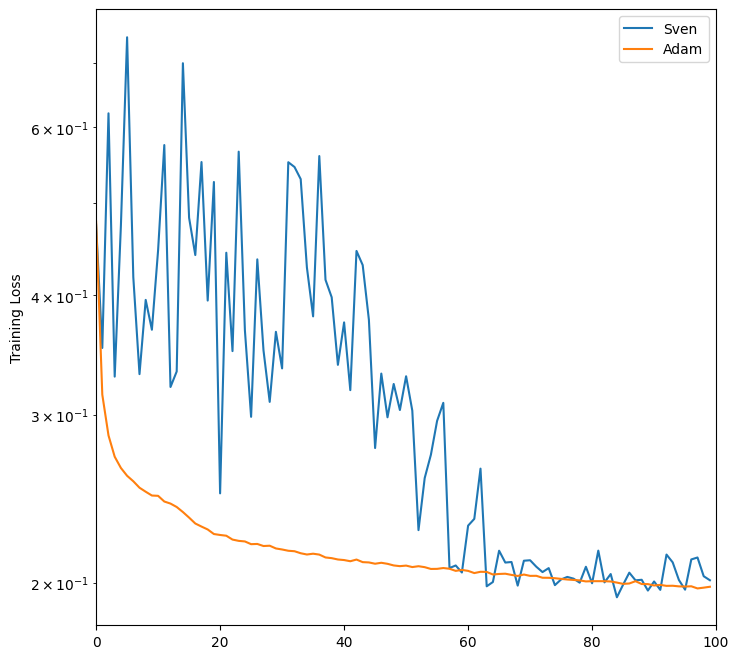

In [11]:
plt.figure(figsize=(8, 8))
plt.plot(losses_svd['train'], label='Sven')
plt.plot(losses_adam['train'], label='Adam')
plt.legend()
plt.ylabel("Training Loss")
plt.yscale('log')
plt.xlim([0, n_epoch])

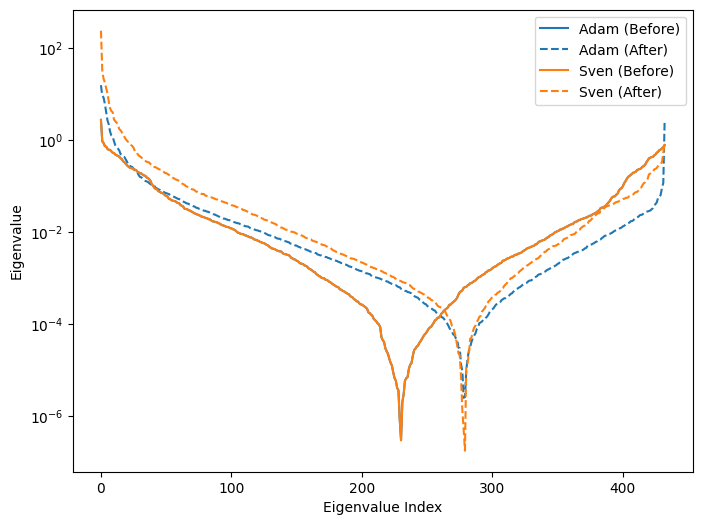

In [12]:
plt.figure(figsize=(8, 6))
plt.plot(np.abs(eigs_pre[::-1]),       label='Adam (Before)', color='C0')
plt.plot(np.abs(eigs_post[::-1]),      label='Adam (After)',  color='C0', linestyle='--')
plt.plot(np.abs(eigs_pre_sven[::-1]),  label='Sven (Before)', color='C1')
plt.plot(np.abs(eigs_post_sven[::-1]), label='Sven (After)',  color='C1', linestyle='--')
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue")
plt.yscale('log')
plt.legend()

<>:7: SyntaxWarning: invalid escape sequence '\|'
<>:7: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_2841304/1141740053.py:7: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel("Eigenvector-Gradient Alignment ($v_i^T g / \|g\|$)")


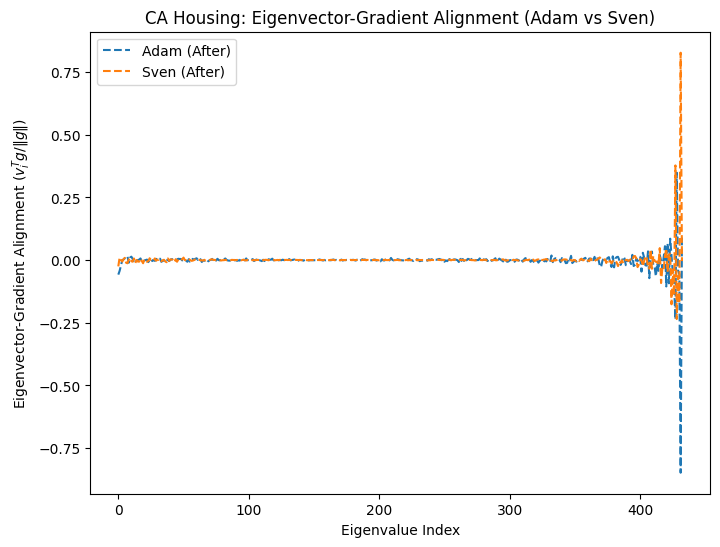

In [13]:
plt.figure(figsize=(8, 6))
#plt.plot(VG_dots_pre,      label='Adam (Before)', color='C0')
plt.plot(VG_dots_post,      label='Adam (After)',  color='C0', linestyle='--')
#plt.plot(VG_dots_pre_sven,  label='Sven (Before)', color='C1')
plt.plot(VG_dots_post_sven, label='Sven (After)',  color='C1', linestyle='--')
plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvector-Gradient Alignment ($v_i^T g / \|g\|$)")
plt.title("CA Housing: Eigenvector-Gradient Alignment (Adam vs Sven)")
plt.legend()

### Candidate Step Alignment (Adam vs Sven)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(VG_dots_post,     label='Gradient (Adam, After)', color='C0', linestyle='--')
axes[0].plot(VS_dots_post_adam, label='Step (Adam, After)',    color='C0', linestyle='-', alpha=0.8)
axes[0].set_xlabel("Eigenvalue Index (Smallest → Largest)")
axes[0].set_ylabel("Alignment")
axes[0].set_title("CA Housing: Adam – Gradient vs Step alignment")
axes[0].legend()

axes[1].plot(VG_dots_post_sven,  label='Gradient (Sven, After)', color='C1', linestyle='--')
axes[1].plot(VS_dots_post_sven,  label='Step (Sven, After)',     color='C1', linestyle='-', alpha=0.8)
axes[1].set_xlabel("Eigenvalue Index (Smallest → Largest)")
axes[1].set_ylabel("Alignment")
axes[1].set_title("CA Housing: Sven – Gradient vs Step alignment")
axes[1].legend()

plt.tight_layout()
plt.show()


# Sarcos Robot Arm Dynamics

### Define dataset

In [17]:
import scipy.io
import urllib.request
import os
from sklearn.preprocessing import StandardScaler

sarcos_train_path = 'sarcos_inv.mat'
sarcos_test_path  = 'sarcos_inv_test.mat'

if not os.path.exists(sarcos_train_path):
    print("Downloading sarcos_inv.mat ...")
    urllib.request.urlretrieve(
        'https://gaussianprocess.org/gpml/data/sarcos_inv.mat', sarcos_train_path)
if not os.path.exists(sarcos_test_path):
    print("Downloading sarcos_inv_test.mat ...")
    urllib.request.urlretrieve(
        'https://gaussianprocess.org/gpml/data/sarcos_inv_test.mat', sarcos_test_path)

train_mat = scipy.io.loadmat(sarcos_train_path)['sarcos_inv'].astype(np.float32)
test_mat  = scipy.io.loadmat(sarcos_test_path)['sarcos_inv_test'].astype(np.float32)

# Columns 0:21 = joint positions/velocities/accelerations (inputs)
# Columns 21:28 = joint torques (outputs)
X_train_s = train_mat[:, :21]
y_train_s = train_mat[:, 21:]
X_test_s  = test_mat[:,  :21]
y_test_s  = test_mat[:,  21:]

scaler_X_s = StandardScaler().fit(X_train_s)
scaler_y_s = StandardScaler().fit(y_train_s)
X_train_s = scaler_X_s.transform(X_train_s)
y_train_s = scaler_y_s.transform(y_train_s)
X_test_s  = scaler_X_s.transform(X_test_s)
y_test_s  = scaler_y_s.transform(y_test_s)

X_train_s = torch.tensor(X_train_s)
y_train_s = torch.tensor(y_train_s)
X_test_s  = torch.tensor(X_test_s)
y_test_s  = torch.tensor(y_test_s)

train_dataset = TensorDataset(X_train_s, y_train_s)
val_dataset   = TensorDataset(X_test_s,  y_test_s)
print(f"Train: {X_train_s.shape}, Val: {X_test_s.shape}")
print(f"Input dim: {X_train_s.shape[1]}, Output dim: {y_train_s.shape[1]}")

Train: torch.Size([44484, 21]), Val: torch.Size([4449, 21])
Input dim: 21, Output dim: 7


### Define model

In [18]:
# 21 -> [128, 128] -> 7  (~20K parameters; 7-output multi-task regression)
def make_model():
    return MLP(input_dim=21, hidden_dims=[128, 128], output_dim=7)

m_tmp = make_model()
n_params = sum(p.numel() for p in m_tmp.parameters())
print(f"Parameter count: {n_params:,}")

set_seed(84231)
init_state = copy.deepcopy(m_tmp.state_dict())
del m_tmp

Parameter count: 20,231


### Training params

In [19]:
LOADER_SEED = 12345
batch_size = 256   # larger batches for 44K-sample dataset
n_epoch    = 50
HESS_N     = 500  # subset size for Hessian computation

### Train Adam

In [ ]:
model_adam = make_model().to(device)
model_adam.load_state_dict(init_state)

LR_ADAM = 1e-3
optimizer = torch.optim.Adam(model_adam.parameters(), lr=LR_ADAM)

def loss_fn(pred, y):
    return (pred - y).pow(2).sum(dim=1).mean()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader  = DataLoader(val_dataset,   batch_size=512, shuffle=False)

hess_idx = torch.randperm(len(train_dataset), generator=torch.Generator().manual_seed(12345))[:HESS_N]
x_pre, y_pre = train_dataset[hess_idx]
H_pre, G_pre = get_hessian(model_adam, x_pre.to(device), y_pre.to(device), loss_fn)
eigs_pre, V_pre = torch.linalg.eigh(H_pre)
VG_dots = V_pre.T @ G_pre / torch.linalg.norm(G_pre,ord=2)
del H_pre, V_pre, G_pre
eigs_pre = eigs_pre.detach().cpu().numpy()
VG_dots = VG_dots.detach().cpu().numpy()
torch.cuda.empty_cache()

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=False)

x_post, y_post = train_dataset[hess_idx]
H_post, G_post = get_hessian(model_adam, x_post.to(device), y_post.to(device), loss_fn)
eigs_post, V_post = torch.linalg.eigh(H_post)
VG_dots_post = V_post.T @ G_post / torch.linalg.norm(G_post, ord=2)

# Compute candidate Adam step alignment before releasing V_post
step_adam = get_avg_adam_step(model_adam, optimizer, train_dataset, loss_fn, n_batches=8, batch_size=batch_size, seed=42)
VS_dots_post_adam = compute_step_alignment(V_post, step_adam, device)

del H_post, G_post, V_post
eigs_post = eigs_post.detach().cpu().numpy()
VG_dots_post = VG_dots_post.detach().cpu().numpy()
torch.cuda.empty_cache()


Loss: 8.210711479187012
Loss: 8.210711479187012
Using device cuda


100%|██████████| 50/50 [00:57<00:00,  1.14s/it]


Loss: 0.09123899042606354
Loss: 0.09123899042606354


### Train Sven

In [ ]:
model_svd = make_model().to(device)
model_svd.load_state_dict(init_state)

def loss_fn(pred, y):
    return (pred - y).pow(2).sum(dim=1)

LR_SVD = 0.5
RTOL   = 1e-3
K      = 64   # larger rank to handle 7 output directions

model_svd = SvenWrapper(model_svd, loss_fn, device=device)
optimizer_sven = Sven(model_svd, lr=LR_SVD, k=K, rtol=RTOL, track_svd_info=True, svd_mode='randomized', use_rmsprop=False)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader  = DataLoader(val_dataset,   batch_size=512, shuffle=False)

hess_idx_sven = torch.randperm(len(train_dataset), generator=torch.Generator().manual_seed(12345))[:HESS_N]
x_pre_sven, y_pre_sven = train_dataset[hess_idx_sven]
H_pre_sven, G_pre_sven = get_hessian_sven(model_svd, x_pre_sven.to(device), y_pre_sven.to(device))
eigs_pre_sven, V_pre_sven = torch.linalg.eigh(H_pre_sven)
VG_dots_sven = V_pre_sven.T @ G_pre_sven / torch.linalg.norm(G_pre_sven,ord=2)
del H_pre_sven, V_pre_sven, G_pre_sven
eigs_pre_sven = eigs_pre_sven.detach().cpu().numpy()
VG_dots_sven = VG_dots_sven.detach().cpu().numpy()
torch.cuda.empty_cache()

model_svd, losses_svd, optimizer_sven = train_loop_svd(model_svd, optimizer_sven, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=False)
svd_info = optimizer_sven.svd_info

x_post_sven, y_post_sven = train_dataset[hess_idx_sven]
H_post_sven, G_post_sven = get_hessian_sven(model_svd, x_post_sven.to(device), y_post_sven.to(device))
eigs_post_sven, V_post_sven = torch.linalg.eigh(H_post_sven)
VG_dots_post_sven = V_post_sven.T @ G_post_sven / torch.linalg.norm(G_post_sven, ord=2)

# Compute candidate Sven step alignment before releasing V_post_sven
step_sven = get_avg_sven_step(model_svd, optimizer_sven, train_dataset, n_batches=8, batch_size=batch_size, seed=42)
VS_dots_post_sven = compute_step_alignment(V_post_sven, step_sven, device)

del H_post_sven, G_post_sven, V_post_sven
eigs_post_sven = eigs_post_sven.detach().cpu().numpy()
VG_dots_post_sven = VG_dots_post_sven.detach().cpu().numpy()
torch.cuda.empty_cache()


Loss: 8.210711479187012
Loss: 8.210711479187012


100%|██████████| 50/50 [01:51<00:00,  2.22s/it]


Loss: 0.1082734763622284
Loss: 0.1082734763622284


### Compare

(0.0, 50.0)

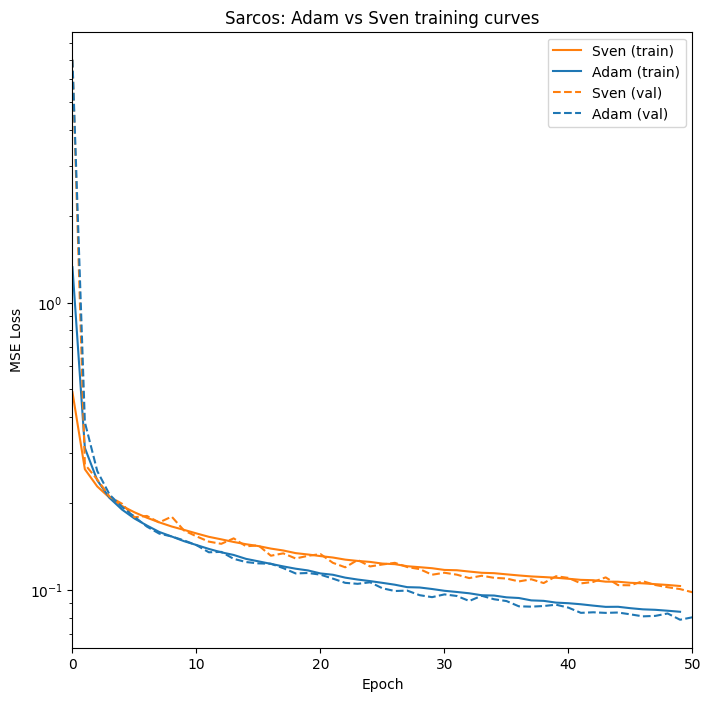

In [22]:
plt.figure(figsize=(8, 8))
plt.plot(losses_svd['train'],  label='Sven (train)',  color='C1')
plt.plot(losses_adam['train'], label='Adam (train)',  color='C0')
plt.plot(losses_svd['val'],    label='Sven (val)',    color='C1', linestyle='--')
plt.plot(losses_adam['val'],   label='Adam (val)',    color='C0', linestyle='--')
plt.legend()
plt.ylabel("MSE Loss")
plt.xlabel("Epoch")
plt.title("Sarcos: Adam vs Sven training curves")
plt.yscale('log')
plt.xlim([0, n_epoch])

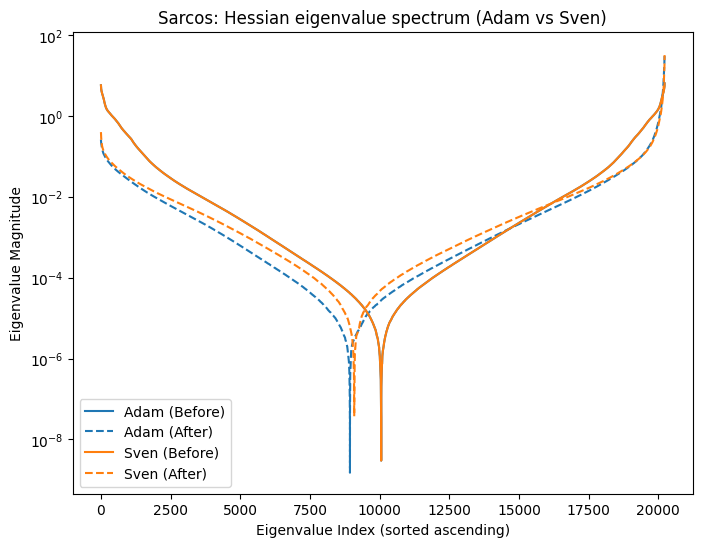

In [25]:
plt.figure(figsize=(8, 6))
plt.plot(np.abs(eigs_pre),       label='Adam (Before)', color='C0')
plt.plot(np.abs(eigs_post),      label='Adam (After)',  color='C0', linestyle='--')
plt.plot(np.abs(eigs_pre_sven),  label='Sven (Before)', color='C1')
plt.plot(np.abs(eigs_post_sven), label='Sven (After)',  color='C1', linestyle='--')
plt.xlabel("Eigenvalue Index (sorted ascending)")
plt.ylabel("Eigenvalue Magnitude")
plt.title("Sarcos: Hessian eigenvalue spectrum (Adam vs Sven)")
plt.yscale('log')
plt.legend()

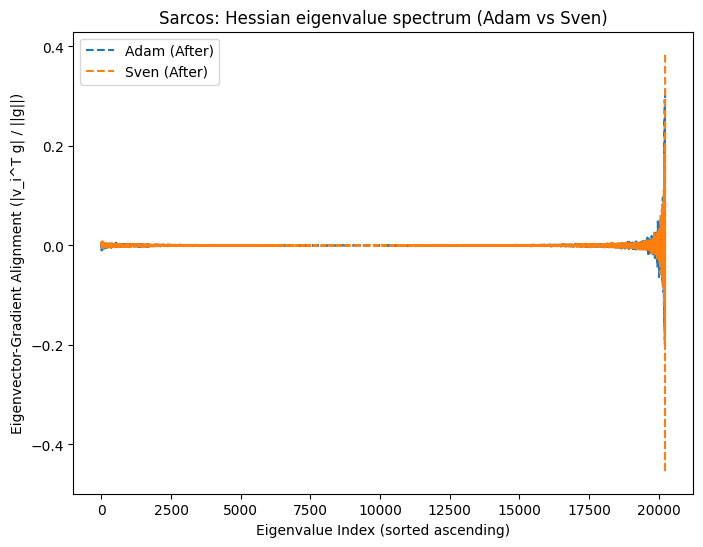

In [26]:
plt.figure(figsize=(8, 6))
#plt.plot(VG_dots,       label='Adam (Before)', color='C0')
plt.plot(VG_dots_post,      label='Adam (After)',  color='C0', linestyle='--')
#plt.plot(VG_dots_sven,  label='Sven (Before)', color='C1')
plt.plot(VG_dots_post_sven, label='Sven (After)',  color='C1', linestyle='--')
plt.xlabel("Eigenvalue Index (sorted ascending)")
plt.ylabel("Eigenvector-Gradient Alignment (|v_i^T g| / ||g||)")
plt.title("Sarcos: Hessian eigenvalue spectrum (Adam vs Sven)")
#plt.yscale('log')
plt.legend()

### Candidate Step Alignment (Adam vs Sven)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(VG_dots_post,     label='Gradient (Adam, After)', color='C0', linestyle='--')
axes[0].plot(VS_dots_post_adam, label='Step (Adam, After)',    color='C0', linestyle='-', alpha=0.8)
axes[0].set_xlabel("Eigenvalue Index (Smallest → Largest)")
axes[0].set_ylabel("Alignment")
axes[0].set_title("Sarcos: Adam – Gradient vs Step alignment")
axes[0].legend()

axes[1].plot(VG_dots_post_sven,  label='Gradient (Sven, After)', color='C1', linestyle='--')
axes[1].plot(VS_dots_post_sven,  label='Step (Sven, After)',     color='C1', linestyle='-', alpha=0.8)
axes[1].set_xlabel("Eigenvalue Index (Smallest → Largest)")
axes[1].set_ylabel("Alignment")
axes[1].set_title("Sarcos: Sven – Gradient vs Step alignment")
axes[1].legend()

plt.tight_layout()
plt.show()
